In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 5)

# Parameter sinyal
f_signal = 1000       # frekuensi sinyal = 1 kHz
duration = 0.01       # durasi sinyal = 10 ms

# Membuat representasi sinyal analog yang sangat rapat
t_analog = np.linspace(
    0,
    duration,
    100000,
    endpoint=False
)

x_analog = np.sin(2 * np.pi * f_signal * t_analog)

print("Frekuensi sinyal :", f_signal, "Hz")
print("Durasi           :", duration, "detik")

Frekuensi sinyal : 1000 Hz
Durasi           : 0.01 detik


In [2]:
fmax = 1000

fs_min = 2 * fmax

print("fmax =", fmax, "Hz")
print("Frekuensi sampling minimum =", fs_min, "Hz")
print("Frekuensi sampling minimum =", fs_min / 1000, "kHz")

fmax = 1000 Hz
Frekuensi sampling minimum = 2000 Hz
Frekuensi sampling minimum = 2.0 kHz


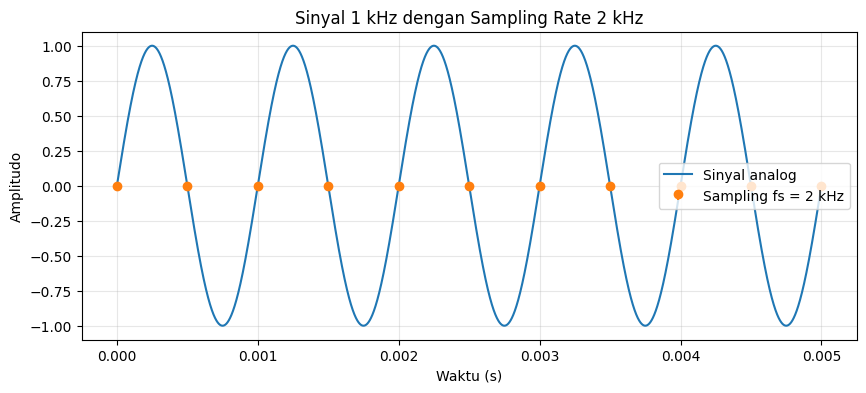

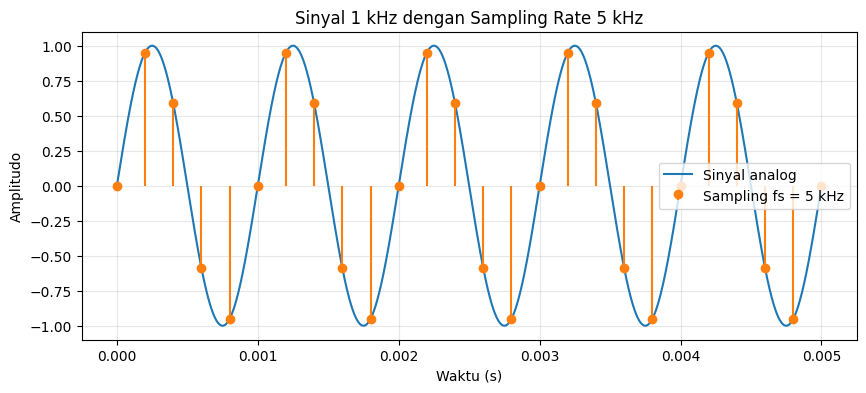

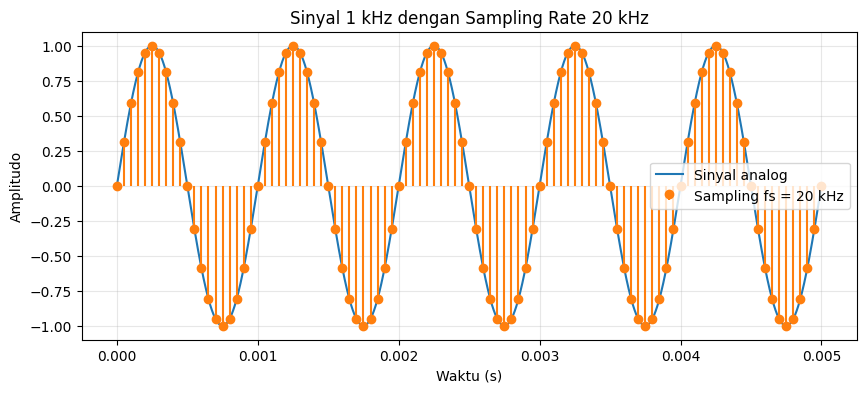

In [3]:
sampling_rates = [2000, 5000, 20000]

for fs in sampling_rates:

    # Membuat waktu sampling
    t_sample = np.arange(
        0,
        duration,
        1 / fs
    )

    # Sampling sinyal
    x_sample = np.sin(
        2 * np.pi * f_signal * t_sample
    )

    # Membatasi grafik sampai 5 ms
    mask_analog = t_analog <= 0.005
    mask_sample = t_sample <= 0.005

    plt.figure(figsize=(10, 4))

    # Sinyal analog
    plt.plot(
        t_analog[mask_analog],
        x_analog[mask_analog],
        label="Sinyal analog"
    )

    # Titik sampling
    plt.stem(
        t_sample[mask_sample],
        x_sample[mask_sample],
        linefmt="C1-",
        markerfmt="C1o",
        basefmt=" ",
        label=f"Sampling fs = {fs/1000:g} kHz"
    )

    plt.title(
        f"Sinyal 1 kHz dengan Sampling Rate {fs/1000:g} kHz"
    )

    plt.xlabel("Waktu (s)")
    plt.ylabel("Amplitudo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [4]:
def calculate_alias_frequency(f_signal, fs):

    # Menghitung frekuensi alias
    k = int(round(f_signal / fs))

    f_alias = abs(f_signal - k * fs)

    # Melipat frekuensi ke daerah 0 sampai fs/2
    if f_alias > fs / 2:
        f_alias = fs - f_alias

    return f_alias


sampling_test = [
    500,
    1500,
    2000,
    5000,
    20000
]

results = []

for fs in sampling_test:

    nyquist = fs / 2
    alias_frequency = calculate_alias_frequency(
        f_signal,
        fs
    )

    if fs < 2 * f_signal:
        aliasing = "Ya"
    else:
        aliasing = "Tidak (ideal)"

    results.append([
        fs,
        nyquist,
        aliasing,
        alias_frequency
    ])


alias_df = pd.DataFrame(
    results,
    columns=[
        "Sampling Rate (Hz)",
        "Frekuensi Nyquist (Hz)",
        "Aliasing",
        "Frekuensi Alias (Hz)"
    ]
)

display(alias_df)

,Sampling Rate (Hz),Frekuensi Nyquist (Hz),Aliasing,Frekuensi Alias (Hz)
0,500,250.0,Ya,0
1,1500,750.0,Ya,500
2,2000,1000.0,Tidak (ideal),1000
3,5000,2500.0,Tidak (ideal),1000
4,20000,10000.0,Tidak (ideal),1000


In [5]:
def quantize_signal(
    signal,
    bits,
    vmin=-1,
    vmax=1
):

    # Jumlah level
    L = 2 ** bits

    # Step size
    delta = (vmax - vmin) / L

    # Menentukan indeks level
    q_index = np.floor(
        (signal - vmin) / delta
    )

    # Membatasi indeks
    q_index = np.clip(
        q_index,
        0,
        L - 1
    )

    # Nilai hasil kuantisasi
    quantized = (
        vmin
        + (q_index + 0.5) * delta
    )

    return quantized, L, delta

In [6]:
bit_depths = [4, 8, 16]

quantization_results = []

for bits in bit_depths:

    x_quantized, levels, delta = quantize_signal(
        x_analog,
        bits
    )

    # Mean Squared Error
    mse = np.mean(
        (x_analog - x_quantized) ** 2
    )

    # Error maksimum teori
    max_error = delta / 2

    quantization_results.append([
        bits,
        levels,
        delta,
        mse,
        max_error
    ])


quantization_df = pd.DataFrame(
    quantization_results,
    columns=[
        "Bit Depth",
        "Jumlah Level",
        "Step Size",
        "MSE",
        "Error Maksimum Teori"
    ]
)

display(quantization_df)

,Bit Depth,Jumlah Level,Step Size,MSE,Error Maksimum Teori
0,4,16,0.125000,1.470727e-03,0.062500
1,8,256,0.007812,5.250329e-06,0.003906
2,16,65536,0.000031,7.755457e-11,0.000015


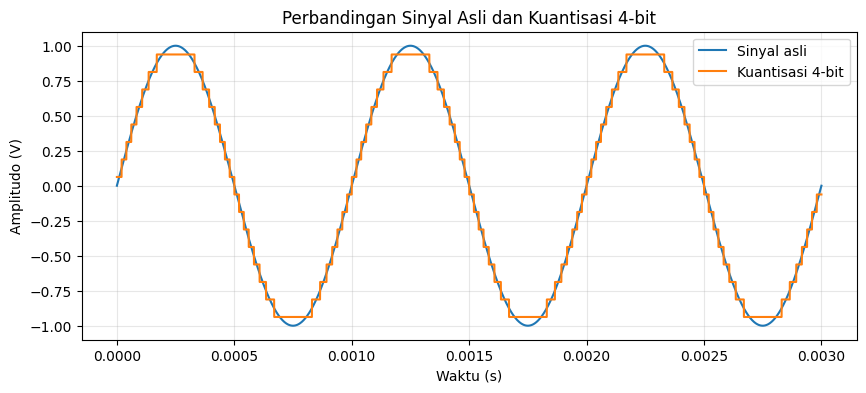

4-bit | Level = 16 | MSE = 1.470727e-03


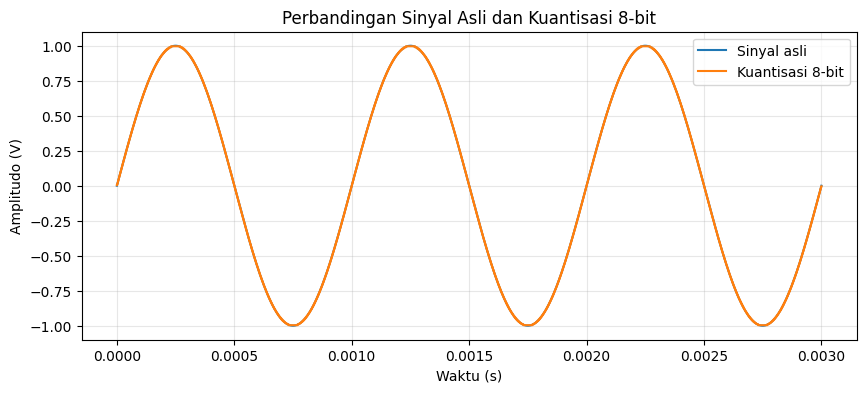

8-bit | Level = 256 | MSE = 5.250329e-06


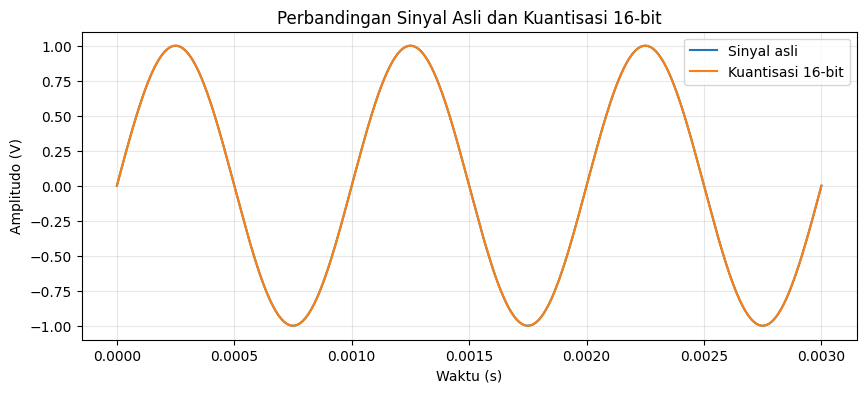

16-bit | Level = 65536 | MSE = 7.755457e-11


In [7]:
zoom = t_analog <= 0.003

for bits in [4, 8, 16]:

    x_quantized, levels, delta = quantize_signal(
        x_analog,
        bits
    )

    mse = np.mean(
        (x_analog - x_quantized) ** 2
    )

    plt.figure(figsize=(10, 4))

    plt.plot(
        t_analog[zoom],
        x_analog[zoom],
        label="Sinyal asli"
    )

    plt.plot(
        t_analog[zoom],
        x_quantized[zoom],
        label=f"Kuantisasi {bits}-bit"
    )

    plt.title(
        f"Perbandingan Sinyal Asli dan Kuantisasi {bits}-bit"
    )

    plt.xlabel("Waktu (s)")
    plt.ylabel("Amplitudo (V)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

    print(
        f"{bits}-bit | "
        f"Level = {levels} | "
        f"MSE = {mse:.6e}"
    )

In [8]:
summary = []

for bits in [4, 8, 16]:

    xq, L, delta = quantize_signal(
        x_analog,
        bits
    )

    mse = np.mean(
        (x_analog - xq) ** 2
    )

    if bits == 4:
        interpretation = "Error relatif besar dan bentuk bertangga"
    elif bits == 8:
        interpretation = "Representasi lebih halus"
    else:
        interpretation = "Representasi sangat halus, error sangat kecil"

    summary.append([
        bits,
        L,
        mse,
        interpretation
    ])


summary_df = pd.DataFrame(
    summary,
    columns=[
        "Bit Depth",
        "Jumlah Level",
        "MSE",
        "Interpretasi"
    ]
)

display(summary_df)

,Bit Depth,Jumlah Level,MSE,Interpretasi
0,4,16,1.470727e-03,Error relatif besar dan bentuk bertangga
1,8,256,5.250329e-06,Representasi lebih halus
2,16,65536,7.755457e-11,"Representasi sangat halus, error sangat kecil"


In [9]:
# Verifikasi jumlah level
assert 2**4 == 16
assert 2**8 == 256
assert 2**16 == 65536

# Verifikasi Nyquist
assert 2000 >= 2 * 1000
assert 5000 >= 2 * 1000
assert 20000 >= 2 * 1000

print("Semua verifikasi berhasil.")

Semua verifikasi berhasil.


In [10]:
# ============================================================
# RINGKASAN AKHIR SIMULASI ADC
# ============================================================

print("=" * 60)
print("RINGKASAN SIMULASI ADC")
print("=" * 60)

# Parameter utama
print("\nPARAMETER SINYAL")
print("Frekuensi sinyal :", f_signal, "Hz")
print("fmax              :", fmax, "Hz")
print("Nyquist minimum   :", fs_min, "Hz")
print("Rentang ADC       : -1 V sampai +1 V")

# Sampling
print("\nHASIL SAMPLING")

for fs in [2000, 5000, 20000]:

    jumlah_sampel = int(fs * duration)

    if fs < 2 * f_signal:
        kondisi = "ALIASING"
    elif fs == 2 * f_signal:
        kondisi = "BATAS NYQUIST"
    else:
        kondisi = "AMAN"

    print(
        f"fs = {fs:5d} Hz | "
        f"Sampel = {jumlah_sampel:4d} | "
        f"{kondisi}"
    )

# Kuantisasi
print("\nHASIL KUANTISASI")

for bits in [4, 8, 16]:

    xq, levels, delta = quantize_signal(
        x_analog,
        bits
    )

    mse = np.mean(
        (x_analog - xq) ** 2
    )

    print(
        f"{bits:2d}-bit | "
        f"Level = {levels:6d} | "
        f"Delta = {delta:.8f} V | "
        f"MSE = {mse:.6e}"
    )

print("\nSimulasi selesai.")

RINGKASAN SIMULASI ADC

PARAMETER SINYAL
Frekuensi sinyal : 1000 Hz
fmax              : 1000 Hz
Nyquist minimum   : 2000 Hz
Rentang ADC       : -1 V sampai +1 V

HASIL SAMPLING
fs =  2000 Hz | Sampel =   20 | BATAS NYQUIST
fs =  5000 Hz | Sampel =   50 | AMAN
fs = 20000 Hz | Sampel =  200 | AMAN

HASIL KUANTISASI
 4-bit | Level =     16 | Delta = 0.12500000 V | MSE = 1.470727e-03
 8-bit | Level =    256 | Delta = 0.00781250 V | MSE = 5.250329e-06
16-bit | Level =  65536 | Delta = 0.00003052 V | MSE = 7.755457e-11

Simulasi selesai.
